Solver - refer to Solve Equation

In [1]:
from sympy import *
x, y, z = symbols('x y z')
init_printing(use_unicode=True)

In [2]:
# in equation, not use = or == but by Eq
Eq(x, y)  # means x = y

In [ ]:
# in Sympy, any expression not in an Eq is automatically assumed to equal 0 by the solving function
solveset(Eq(x**2, 1), x)  # means x**2 = 1,  x means refer to x

In [4]:
solveset(Eq(x**2 -1, 0), x)  # means x**2 - 1 = 0

In [ ]:
# use solveset, we can omit Eq()
solveset(x**2 -1, x)  # means x**2 - 1 = 0

Solving Equations Algebraically

In [ ]:
solveset(x**2 -x, x)

In [ ]:
solveset(x - x, x, domain=S.Reals)

In [8]:
solveset(sin(x) - 1, x, domain=S.Reals)

In [ ]:
# if there are no solution, an EmptySet is returned
# if it is not able to find solutions then a ConditionalSet is returned
solveset(exp(x), x)  # no solution exists

In [ ]:
solveset(cos(x) - x, x)   # not able to find solution

In [11]:
# in the solveset module, the linear system of equations is solved using linsolve.
# list of Equation Form
linsolve([x + y + z - 1, x + y + 2*z - 3], (x, y, z))

In [12]:
# Argumented Matrix Form
linsolve(Matrix(([1, 1, 1, 1], [1, 1, 2, 3])), (x, y, z))

In [13]:
# A*x = b From
M = Matrix(((1, 1, 1, 1), (1, 1, 2, 3)))
system = A, b = M[:, :-1], M[:, -1]
linsolve(system, x, y, z)

In [14]:
# In the solveset module, the non linear system of equations is solved using nonlinsolve.
# When only real solution is present
a, b, c, d = symbols('a b c d', real=True)
nonlinsolve([a**2 + a, a - b], [a, b])

In [15]:
nonlinsolve([x*y - 1, x - 2], x, y)   # if x*y - 1 = 0 or x -2 = 0

In [16]:
# when only complex solution is present
nonlinsolve([x**2 + 1, y**2 + 1], [x, y])

In [17]:

# When both real and complex solution are present:
from sympy import sqrt
system = [x**2 - 2*y**2 - 2, x*y -2]
vars = [x, y]
nonlinsolve(system, vars)

In [18]:
system = [exp(x) - sin(y), 1/y - 3]
nonlinsolve(system, vars)

In [19]:
# when the system is positive-dimensional system (has infinitely many solutions)
nonlinsolve([x*y, x*y - x], [x, y])

In [20]:
system = [a**2 + a*c, a - b]
nonlinsolve(system, [a, b])

In [21]:
# currently nonlinsolve doesn't return solution in form of LambertW
solve([x**2 -y**2/exp(x)], [x, y], dict=True)

In [22]:
solve(x**2 - y**2/exp(x), x, dict=True)

In [23]:
# Currently nonlinsolve is not properly capable of solving the system of equations having trigonometric func
# solve can be used for such cases (but does not give all solution)
solve([sin(x + y), cos(x - y)], [x, y])

In [24]:
# solveset reports each solution only once.
# To get the solutions of a polynomial including multiplicity use 'roots'
solveset(x**3 - 6*x**2 + 9*x, x)

In [25]:
roots(x**3 - 6*x**2 + 9*x, x)

In [26]:
# above means that 0 is a root of multiplicity 1 and 3 is a root of multiplicity 2

Currently solveset is not capable of solving the following types of equations

- Equations solvable by LambertW (Transcendental equation solver)


In [27]:
solve(x*exp(x) - 1, x)

Solving Differential Equations

- to solve differential equations, use dsolve.
- First, create an undefined function by passing cls=Function to the symbols function

In [28]:
f, g = symbols('f g', cls=Function)
# f and g are now undefined functions. We can call f(x), and it will represent an unknown function
f(x)

In [29]:
# Derivatives of f(x) are unevaluated
f(x).diff(x)

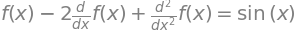

In [30]:
# To represent the differential equation f"(x) - 2f'(x) + f(x) = sin(x), we would thus use
diffeq = Eq(f(x).diff(x, x) - 2*f(x).diff(x) + f(x), sin(x))
diffeq 

In [31]:
# to solve the ODE, pass it and the function to solve for to dsolve
dsolve(diffeq, f(x))

In [32]:
# dsolve returns an instance of Eq. 
# Because in general, solutions to differential equations cannot be solved  explicitly for the function
dsolve(f(x).diff(x) * (1 - sin(f(x))) - 1, f(x))

In [ ]:
# The abilitrary constants in the solutions from dsolve are symbols of the form C1, C2, C3, and so on.